In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 나눔 폰트 확인 또는 기본 폰트 설정
# 폰트가 없다면 아래 명령어로 설치 가능: !apt-get install -y fonts-nanum
plt.rc('font', family='DejaVu Sans') # 한글이 깨지면 'NanumGothic' 설치 후 변경
plt.rcParams['axes.unicode_minus'] = False

### 1. 데이터 로드 및 기본 구조 파악
가장 먼저 데이터를 DataFrame으로 변환하고, 각 파일의 데이터 개수와 결측치를 확인합니다.

In [10]:
import pandas as pd
import json

# 데이터 로드
docs_df = pd.DataFrame(load_jsonl('/home/AY/data/documents.jsonl'))
eval_df = pd.DataFrame(load_jsonl('/home/AY/data/eval.jsonl'))

# 기본 정보 출력
print(f"Total Documents: {len(docs_df)}")
print(f"Total Eval Queries: {len(eval_df)}")
print("\n[Documents Sample]")
display(docs_df.head(3))
print("\n[Eval Sample]")
display(eval_df.head(3))

Total Documents: 4272
Total Eval Queries: 220

[Documents Sample]


,docid,src,content
0,42508ee0-c543-4338-878e-d98c6babee66,ko_mmlu__nutrition__test,건강한 사람이 에너지 균형을 평형 상태로 유지하는 것은 중요합니다. 에너지 균형은 ...
1,4a437e7f-16c1-4c62-96b9-f173d44f4339,ko_mmlu__conceptual_physics__test,"수소, 산소, 질소 가스의 혼합물에서 평균 속도가 가장 빠른 분자는 수소입니다. 수..."
2,d3c68be5-9cb1-4d6e-ba18-5f81cf89affb,ko_ai2_arc__ARC_Challenge__test,종이와 플라스틱은 재활용 가능한 자원입니다. 중학교 과학 수업에서 우리는 종이와 플...



[Eval Sample]


,eval_id,msg
0,78,"[{'role': 'user', 'content': '나무의 분류에 대해 조사해 보..."
1,213,"[{'role': 'user', 'content': '각 나라에서의 공교육 지출 현..."
2,107,"[{'role': 'user', 'content': '기억 상실증 걸리면 너무 무섭..."


### 2. 소스(src)별 문서 분포 분석
IR 대회에서는 특정 소스에서 온 문서의 비중이 높을 수 있습니다. 어떤 도메인(영양, 물리, 과학 등)이 주를 이루는지 확인합니다.

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 시스템에 나눔 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# matplotlib 폰트 캐시 삭제 (설치 후 한 번은 실행해야 인식됩니다)
fm._rebuild() if hasattr(fm, '_rebuild') else None

Reading package lists... Done
Building dependency tree       
Reading state information... Done
fonts-nanum is already the newest version (20180306-3).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

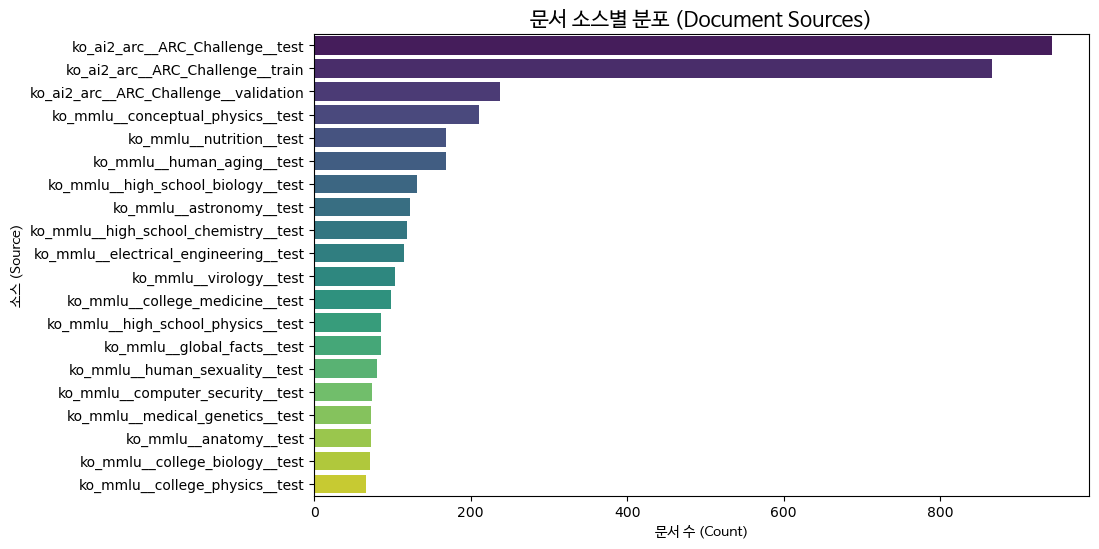

Source Statistics:
src
ko_ai2_arc__ARC_Challenge__test          943
ko_ai2_arc__ARC_Challenge__train         866
ko_ai2_arc__ARC_Challenge__validation    238
ko_mmlu__conceptual_physics__test        211
ko_mmlu__nutrition__test                 168
ko_mmlu__human_aging__test               168
ko_mmlu__high_school_biology__test       131
ko_mmlu__astronomy__test                 122
ko_mmlu__high_school_chemistry__test     118
ko_mmlu__electrical_engineering__test    115
ko_mmlu__virology__test                  103
ko_mmlu__college_medicine__test           98
ko_mmlu__high_school_physics__test        85
ko_mmlu__global_facts__test               85
ko_mmlu__human_sexuality__test            80
ko_mmlu__computer_security__test          74
ko_mmlu__medical_genetics__test           73
ko_mmlu__anatomy__test                    72
ko_mmlu__college_biology__test            71
ko_mmlu__college_physics__test            66
Name: count, dtype: int64


In [22]:
# 폰트 경로 설정 (설치된 나눔바른고딕 사용)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 데이터 집계
src_counts = docs_df['src'].value_counts().head(20)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=src_counts.values, y=src_counts.index, palette='viridis')

# 한글 제목 및 라벨 설정
plt.title('문서 소스별 분포 (Document Sources)', fontproperties=font_prop, fontsize=15)
plt.xlabel('문서 수 (Count)', fontproperties=font_prop)
plt.ylabel('소스 (Source)', fontproperties=font_prop)
plt.show()

print("Source Statistics:")
print(src_counts)

#### [분석 결과]
1. 도메인 편중: 
    - 상위권을 차지한 ko_ai2_arc와 ko_mmlu는 모두 인공지능 성능 측정용 상식 및 과학 문제 데이터셋입니다.
    - 주제가 물리, 영양학, 생물, 천문학 등 매우 광범위합니다. 특정 분야의 전문 용어보다는 보편적인 과학 원리나 학술적 정의를 다루는 모델(예: Ko-Sentence-BERT)이 유리할 것입니다.
2. 데이터 혼합: 
    - test, train, validation 태그가 달린 소스들이 하나의 documents.jsonl에 섞여 있습니다.
    - 검색 대상(Corpus) 안에 원래는 훈련용이었던 데이터들이 섞여 있는 상태입니다. 검색 결과가 너무 완벽하게 나올 경우, 실제 정답 문장이 소스 이름만 다른 중복 데이터는 아닌지 꼭 체크해야 합니다.

=======================================================================================

### 3. 문서 및 쿼리 텍스트 길이 분석
검색 모델(특히 Dense Retrieval)은 입력 길이에 민감합니다. 문서의 평균 길이와 질문(Query)의 길이를 비교해 봅니다.

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

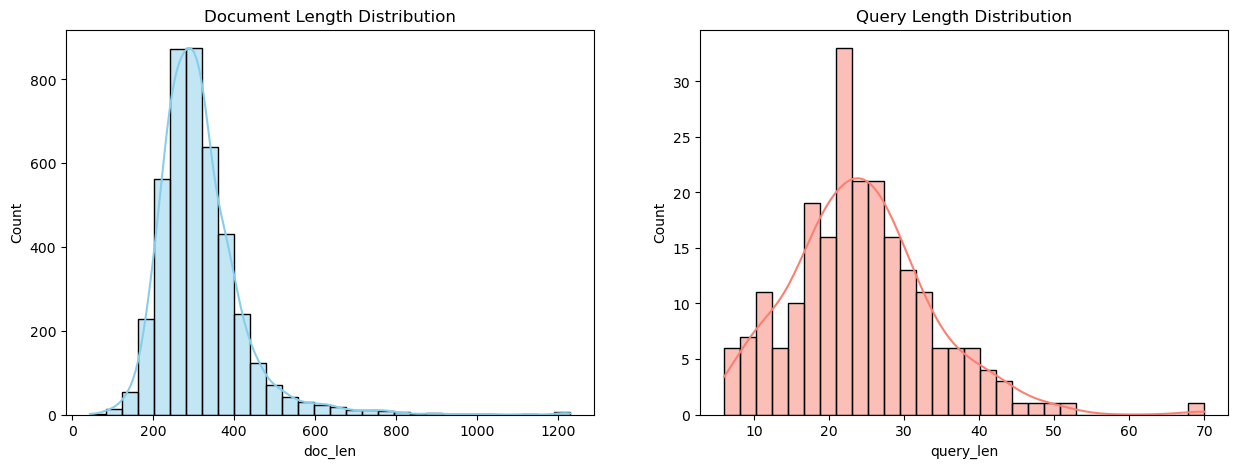

Avg Doc Length: 315.33
Avg Query Length: 24.29


In [23]:
# 문서 길이 계산
docs_df['doc_len'] = docs_df['content'].str.len()

# 쿼리 길이 계산 (eval 데이터의 마지막 유저 질문 추출)
eval_df['query'] = eval_df['msg'].apply(lambda x: x[-1]['content'])
eval_df['query_len'] = eval_df['query'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(docs_df['doc_len'], bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Document Length Distribution')

sns.histplot(eval_df['query_len'], bins=30, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Query Length Distribution')

plt.show()

print(f"Avg Doc Length: {docs_df['doc_len'].mean():.2f}")
print(f"Avg Query Length: {eval_df['query_len'].mean():.2f}")

#### [분석 결과]
1. 문서 길이 (Document Length): 대부분의 문서가 200~400자 사이에 밀집되어 있습니다.
    - 일반적인 BERT 계열 모델의 Max Sequence Length(보통 512 토큰) 안에 충분히 들어오는 크기입니다. 문서를 억지로 자르는 Chunking 과정 없이도 거의 모든 텍스트 정보를 온전히 임베딩할 수 있다는 아주 기쁜 소식이죠!
    - 주의: 1,000자가 넘어가는 긴 꼬리(Long-tail) 문서들은 드물지만 존재하므로, 이들에 대해서만 간단한 전처리를 고려하면 됩니다.

2. 질문 길이 (Query Length):
    - 주로 20~30자 내외의 짧은 문장입니다.
    - 질문이 짧다는 것은 정보가 압축되어 있다는 뜻입니다. 키워드 매칭(BM25)만으로는 동의어나 문맥을 파악하기 어려울 수 있으니, 의미적 유사도를 계산하는 Dense Retrieval(임베딩 기반 검색)의 역할이 매우 중요해 보입니다.

|분석 포인트|특징|추천 전략|
|------|---|---|
|문서 크기|약 300자 내외 (균일)|별도의 Chunking 없이 전체 텍스트 인덱싱|
|질문 형태|짧은 구어체/문어체 혼합|Hybrid Search (BM25 + Dense) 권장|
|데이터 도메인|과학/상식 (ARC, MMLU)|과학 기술 특화 임베딩 모델 사용 검토|

### 4. 텍스트 데이터의 어휘 분석 (Word Cloud)
문서 집합에서 자주 등장하는 키워드를 통해 데이터셋의 주요 테마를 시각화합니다.

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

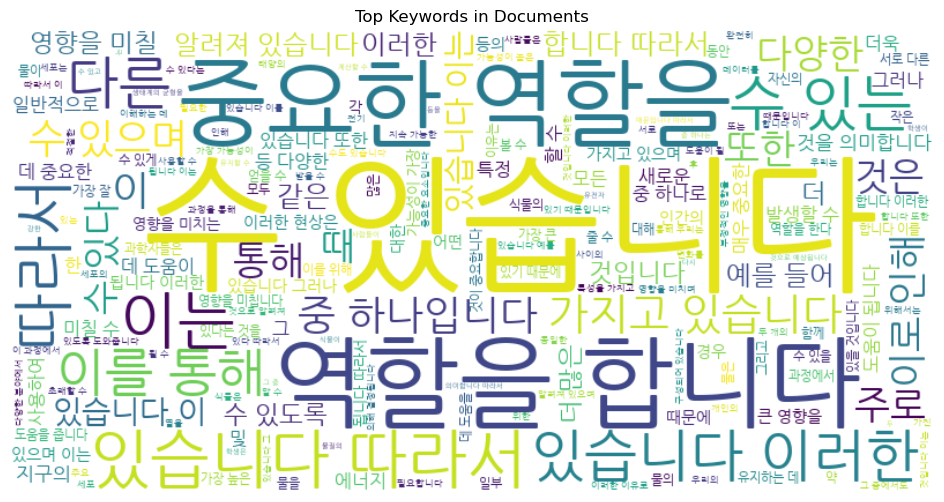

In [24]:
from wordcloud import WordCloud

# 모든 문서의 텍스트 결합
all_text = " ".join(docs_df['content'].tolist())

# 워드클라우드 생성 (폰트 경로 확인 필요)
wc = WordCloud(width=800, height=400, background_color='white', font_path='NanumGothic.ttf').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Documents')
plt.show()

#### [분석 결과]
1. 많이 보이는 의미 없는 단어들
    - 서술어 및 어미: 있습니다, 합니다, 있는, 수, 것은
    - 접속사 및 지시어: 따라서, 이러한, 이를 통해, 중 하나입니다
    - 일반 명사: 역할을, 영향을
2. 격식적인 문제
    - ~습니다, ~합니다가 압도적인 것으로 보아, 문서들이 매우 격식 있고 설명적인 문체(백과사전, 교과서, 논문 등)로 작성되었음
3. 정보 밀도 저하
    - 중요한 '에너지', '수소', '플라스틱' 같은 핵심 키워드들은 구석에 아주 작게 적혀 있습니다. 이는 단순히 띄어쓰기 기준으로 단어를 추출했기 때문에, 한국어의 조사(을/를, 이/가)와 어미가 붙은 단어들이 별개의 단어로 인식되어 빈도수가 분산되었거나, 너무 흔한 단어들이 상단을 차지했기 때문입니다.

[문제점] 이 상태로 검색 모델(BM25 등)을 만들면 검색 성능이 떨어질 가능성이 높습니다.
- 노이즈 발생: 질문에 "무엇이 있습니까?"라고 물으면, 모델이 내용과 상관없이 있습니다가 많이 들어간 엉뚱한 문서를 가져올 수 있습니다.
- 차별성 부족: 모든 문서에 따라서, 중요한이라는 단어가 들어있기 때문에 문서 간의 변별력이 사라집니다.

[해결 방법] 형태소 분석 및 불용어 제거
- 형태소 분석기(Morpheme Analyzer)를 사용해 '명사'만 추출해야 합니다.
- 파이썬 기반 분석기인 Kiwipiepy 사용하기 ⬇️

======================================================================================

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 62.5 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 28.8 MB/s  0:00:00m0:00:01
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067872 sha256=b53fe4199371f2e82eae51835d7ade93bbc6fde884cb066abb3a858e21ac8193
  Stored in directory: /data/ephemeral/home/.cache/pip/wheels/d5/46/96/6ab9ba9f6ccc5f86ccc6e02ca02cdc0dbdc1aeeef40c0b39b1
Successfully built kiwipiepy_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kiwipiepy]model]


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

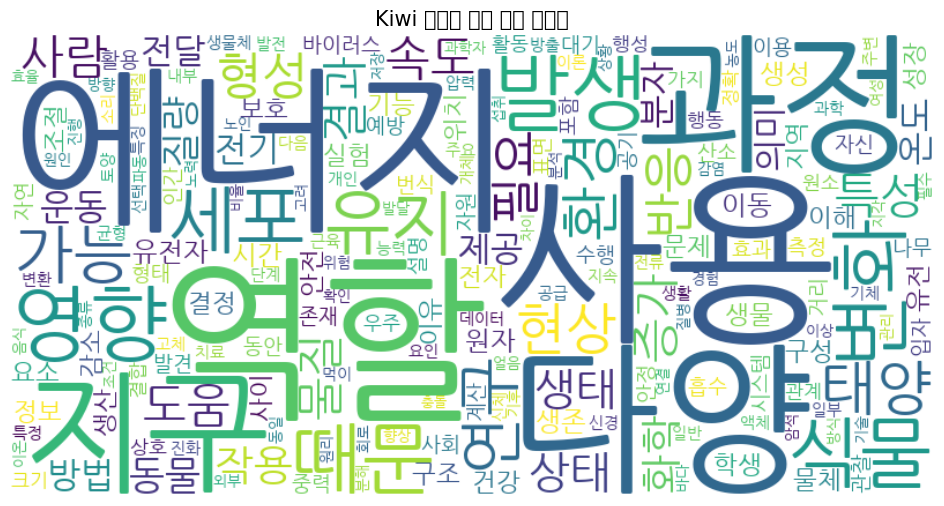

Top 10 Keywords: [('사용', 2000), ('에너지', 1900), ('역할', 1845), ('다양', 1648), ('과정', 1456), ('지구', 1454), ('영향', 1356), ('발생', 1307), ('변화', 1250), ('때문', 1159)]


In [29]:
# 1. 라이브러리 설치
!pip install kiwipiepy

from kiwipiepy import Kiwi
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 2. Kiwi 초기화 및 명사 추출
kiwi = Kiwi()

def extract_nouns(text):
    # 명사(NNG, NNP)만 추출
    result = kiwi.analyze(text)
    return [token.form for token in result[0][0] if token.tag.startswith('NN')]

# 3. 모든 문서에서 명사 추출
all_content = " ".join(docs_df['content'].tolist())
nouns = extract_nouns(all_content)

# 4. 불용어 제거 및 2글자 이상만 남기기
stopwords = ['내용', '분야', '경우', '중요', '통해', '관련', '위해', '대한']
unique_nouns = [n for n in nouns if n not in stopwords and len(n) > 1]

# 5. 빈도수 계산 및 시각화
count = Counter(unique_nouns)
wc_kiwi = WordCloud(
    width=800, height=400, 
    background_color='white', 
    font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf' # 아까 확인한 경로
).generate_from_frequencies(count)

plt.figure(figsize=(12, 6))
plt.imshow(wc_kiwi, interpolation='bilinear')
plt.axis('off')
plt.title('Kiwi 분석기 기반 핵심 키워드', fontsize=15)
plt.show()

print("Top 10 Keywords:", count.most_common(10))

### 5. 중복 문서 및 유사도 체크
동일하거나 매우 유사한 문서가 있으면 성능 평가가 왜곡될 수 있습니다. docid의 중복과 텍스트의 중복을 확인합니다.

In [35]:
# 중복 docid 확인
duplicate_ids = docs_df.duplicated(subset=['docid']).sum()

# 완전 중복 내용 확인
duplicate_content = docs_df.duplicated(subset=['content']).sum()

# 결과 출력
print(f"Number of duplicate docids: {duplicate_ids}")
print(f"Number of documents with identical content: {duplicate_content}")

if duplicate_content > 0:
    print("\n[Example of duplicated content]")
    display(docs_df[docs_df.duplicated(subset=['content'], keep=False)].sort_values(by='content'))

Number of duplicate docids: 0
Number of documents with identical content: 6

[Example of duplicated content]


,docid,src,content,doc_len,top_keywords
2029,d758612c-6dfb-47b4-991d-6f053b282264,ko_mmlu__high_school_physics__test,공기에서 유리창 판으로 들어오는 단색광 빔은 속도와 파장에 변화가 일어납니다. 유리...,166,"빛은, 변하게, 되는데, 일어납니다, 됩니다"
3194,318f4fb1-92d2-4b4c-914f-f9ff8b885aed,ko_mmlu__high_school_physics__test,공기에서 유리창 판으로 들어오는 단색광 빔은 속도와 파장에 변화가 일어납니다. 유리...,166,"빛은, 변하게, 되는데, 일어납니다, 됩니다"
2389,d2145d8e-45aa-4ada-9b82-db197e7ee39a,ko_mmlu__college_physics__train,"굴절 망원경은 굴절 렌즈로 구성되어 있으며, 이는 100 cm로 분리된 두 개의 수...",233,"20, 거리는, 100, 크기를, 얼마나"
4188,b3da4d1b-f001-4632-92ab-bcc6bc9c2cc1,ko_mmlu__college_physics__train,"굴절 망원경은 굴절 렌즈로 구성되어 있으며, 이는 100 cm로 분리된 두 개의 수...",233,"20, 거리는, 100, 크기를, 얼마나"
1494,3ab2de66-dfde-431b-9363-f2671ae02598,ko_mmlu__college_physics__test,단일 전자 원자에서 전자가 l = 2 상태에 있다. 이 상태에서 허용되는 양자수 m...,239,"전자의, 있다, 단일, 상태에, 전자가"
2303,4d4890f1-f158-4628-a26b-d1f34465783a,ko_mmlu__college_physics__test,단일 전자 원자에서 전자가 l = 2 상태에 있다. 이 상태에서 허용되는 양자수 m...,239,"전자의, 있다, 단일, 상태에, 전자가"
2540,91c0d551-8c1f-43c5-b019-916209f8cad6,ko_mmlu__college_physics__test,막대의 길이를 측정하는 관찰자가 막대를 평행하게 움직이면서 측정을 진행해야 합니다....,234,"따라, 속도에, 측정하는, 상태에서, 속도는"
2591,6c8c788c-6d12-4b8b-b216-dcfb51a07f28,ko_mmlu__college_physics__test,막대의 길이를 측정하는 관찰자가 막대를 평행하게 움직이면서 측정을 진행해야 합니다....,234,"따라, 속도에, 측정하는, 상태에서, 속도는"
412,ed487053-8ce6-44c7-a566-57e96b04881b,ko_mmlu__college_physics__test,분광학은 가시 파장의 범위에서 빛의 특성을 연구하는 학문 분야입니다. 이를 위해 가...,262,"좋은, 연구하는, 높이고, 사용되고, 빛의"
1963,6c69f297-2ea2-40d1-ae6c-f038d0b57779,ko_mmlu__college_physics__test,분광학은 가시 파장의 범위에서 빛의 특성을 연구하는 학문 분야입니다. 이를 위해 가...,262,"좋은, 연구하는, 높이고, 사용되고, 빛의"


### [분석 결과]
1. docid 중복 0: 데이터 식별은 깨끗함
    - 모든 문서가 고유한 ID를 가지고 있다는 뜻입니다. 데이터베이스 구조상으로 레코드가 꼬여 있는 기술적 결함은 없습니다.
    - 데이터 로드 과정이나 기본 인덱싱 체계는 아주 건강한 상태입니다.

2. 내용 중복 6개: "같은 내용, 다른 이름"의 존재
    - docid는 다르지만 content와 doc_len이 완전히 일치하는 쌍들이 보입니다. (예: 인덱스 2029번과 3194번)
    - IR 대회에서의 위험 요소: * 평가의 모호성: 만약 질문(Query)에 대한 정답 문서가 2029번인데, 모델이 똑같은 내용인 3194번을 찾아낸다면? 점수 계산 방식에 따라 오답 처리가 될 수도 있습니다.
    - 검색 결과의 중복: 검색 결과 TOP 5를 뽑았는데, 같은 내용이 2개 섞여 있으면 사용자 경험(UX) 측면에서 효율이 떨어집니다.

3. 소스 간 데이터 유출(Leakage) 가능성
    - 예시 테이블의 2389번과 4188번을 보면, 같은 물리학 내용이 서로 다른 소스(college_physics__train 등)에서 중복되어 들어와 있습니다.
    - 훈련 데이터(Train)에 있는 내용이 테스트 데이터(Test)에 그대로 포함되어 있다면, 모델이 "이해"해서 맞추는 게 아니라 "암기"해서 맞출 위험이 있습니다.

[해결 방안]
- 중복 데이터가 6개 정도로 매우 적기 때문에 전체 성능에 치명적이지는 않지만, 깔끔한 모델을 위해 다음 코드를 실행해 중복을 제거한 검색 풀(Pool)을 만드는 것을 추천합니다.⬇️
=====================================================================================

In [ ]:
# 1. 중복된 내용 중 첫 번째 것만 남기고 제거
docs_df_cleaned = docs_df.drop_duplicates(subset=['content'], keep='first')

# 2. 제거 결과 확인
print(f"원본 문서 수: {len(docs_df)}")
print(f"중복 제거 후 문서 수: {len(docs_df_cleaned)}")
print(f"제거된 문서 수: {len(docs_df) - len(docs_df_cleaned)}")

### 6. TF-IDF 분석 코드
documents.jsonl 데이터의 content를 바탕으로 TF-IDF를 계산하고, 각 문서별로 가장 중요한 키워드 5개를 뽑아냅니다.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 1. TF-IDF 벡터화 객체 생성
# 한국어 특성상 띄어쓰기 기준으로 단순 분리합니다. 
# (더 정교한 분석을 원하시면 KoNLPy 같은 형태소 분석기를 사용할 수 있습니다.)
tfidf_vectorizer = TfidfVectorizer(max_features=1000) # 메모리 효율을 위해 상위 1000개 단어만 추출

# 2. 문서 데이터(content)에 TF-IDF 학습 및 변환
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_df['content'])

# 3. 단어 사전(Vocabulary) 가져오기
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# 4. 각 문서별 상위 5개 키워드 추출 함수 정의
def get_top_tf_idf_words(row, features, top_n=5):
    # 해당 문서의 TF-IDF 값을 가져와서 인덱스 정렬
    sorted_indices = np.argsort(row.toarray()).flatten()[::-1]
    top_indices = sorted_indices[:top_n]
    
    # 0보다 큰 가중치를 가진 단어들만 추출 (의미 없는 단어 필터링)
    top_words = [features[i] for i in top_indices if row.toarray()[0, i] > 0]
    return ", ".join(top_words)

# 5. DataFrame에 결과 추가 및 확인
docs_df['top_keywords'] = [get_top_tf_idf_words(row, feature_names) for row in tfidf_matrix]

print("[문서별 TF-IDF 기반 상위 키워드]")
display(docs_df[['docid', 'src', 'content', 'top_keywords']].head(10))

[문서별 TF-IDF 기반 상위 키워드]


,docid,src,content,top_keywords
0,42508ee0-c543-4338-878e-d98c6babee66,ko_mmlu__nutrition__test,건강한 사람이 에너지 균형을 평형 상태로 유지하는 것은 중요합니다. 에너지 균형은 ...,"에너지, 균형을, 기간, 건강한, 운동을"
1,4a437e7f-16c1-4c62-96b9-f173d44f4339,ko_mmlu__conceptual_physics__test,"수소, 산소, 질소 가스의 혼합물에서 평균 속도가 가장 빠른 분자는 수소입니다. 수...","수소, 분자는, 빠른, 평균, 주어진"
2,d3c68be5-9cb1-4d6e-ba18-5f81cf89affb,ko_ai2_arc__ARC_Challenge__test,종이와 플라스틱은 재활용 가능한 자원입니다. 중학교 과학 수업에서 우리는 종이와 플...,"우리는, 가능한, 환경, 자연, 통해"
3,910107a6-2a42-41a2-b337-fbf22d6440fe,ko_ai2_arc__ARC_Challenge__test,마이애미파랑나비는 남부 플로리다에서 멸종 위기에 처한 종입니다. 이 나비의 개체수 ...,"서식지를, 감소하고, 인해, 아니라, 특정한"
4,74f22819-1a8e-4646-8a9d-13323de8cdb8,ko_ai2_arc__ARC_Challenge__validation,"비버는 나무를 베고, 덤불과 관목을 모아 강과 개울에 댐을 만드는 것으로 알려져 있...","개체, 미칠, 서식지를, 수가, 다양한"
5,80feb7f2-1b24-4a9d-87a3-4976e9304e74,ko_mmlu__human_sexuality__test,"AIDS에 직면한 민족문화 공동체 연구에 따르면, 한 해 동안 섹스 파트너가 한 명...","예방, 것이다, 교육, 건강과, 연구는"
6,93c91ff9-641a-4117-bf83-6327d3e382eb,ko_mmlu__virology__test,헤르페스 감염은 화학요법을 통해 통제할 수 있습니다. 화학요법은 항바이러스 약물을 ...,"바이러스의, 증상을, 따라, 것도, 예방하고"
7,418e1e6c-c2de-4ffb-aded-0992fe833776,ko_mmlu__human_aging__test,노인들이 기억력을 향상시키고 기억력 저하에 대한 불안을 줄일 수 있는 경우는 다양합...,"노인들은, 줄일, 것도, 대한, 기술을"
8,69de4a81-3716-4195-973c-39eee3771186,ko_ai2_arc__ARC_Challenge__train,"강한 바람이 삼림 지대의 소나무를 넘어뜨렸을 때, 우거진 숲 지붕에 틈이 생겨 땅에...","강한, 식물이, 인해, 것을, 많이"
9,11cca31a-3997-43fd-a04b-01a2e318d7a2,ko_mmlu__conceptual_physics__test,"광자는 전자기파의 기본 입자로, 전자기파의 에너지를 전달하는 입자입니다. 광자의 에...","에너지와, 기본, 전달하는, 관련된, 관련이"


### 7. 질문 키워드와 문서 소스(src) 교차 분석 (Heatmap)
이 코드는 평가 데이터의 질문에서 가장 많이 등장한 핵심 키워드(상위 15개)를 뽑아내고, 그 키워드들이 상위 10개의 문서 소스에 각각 몇 번이나 등장하는지 매트릭스 형태로 보여줍니다.

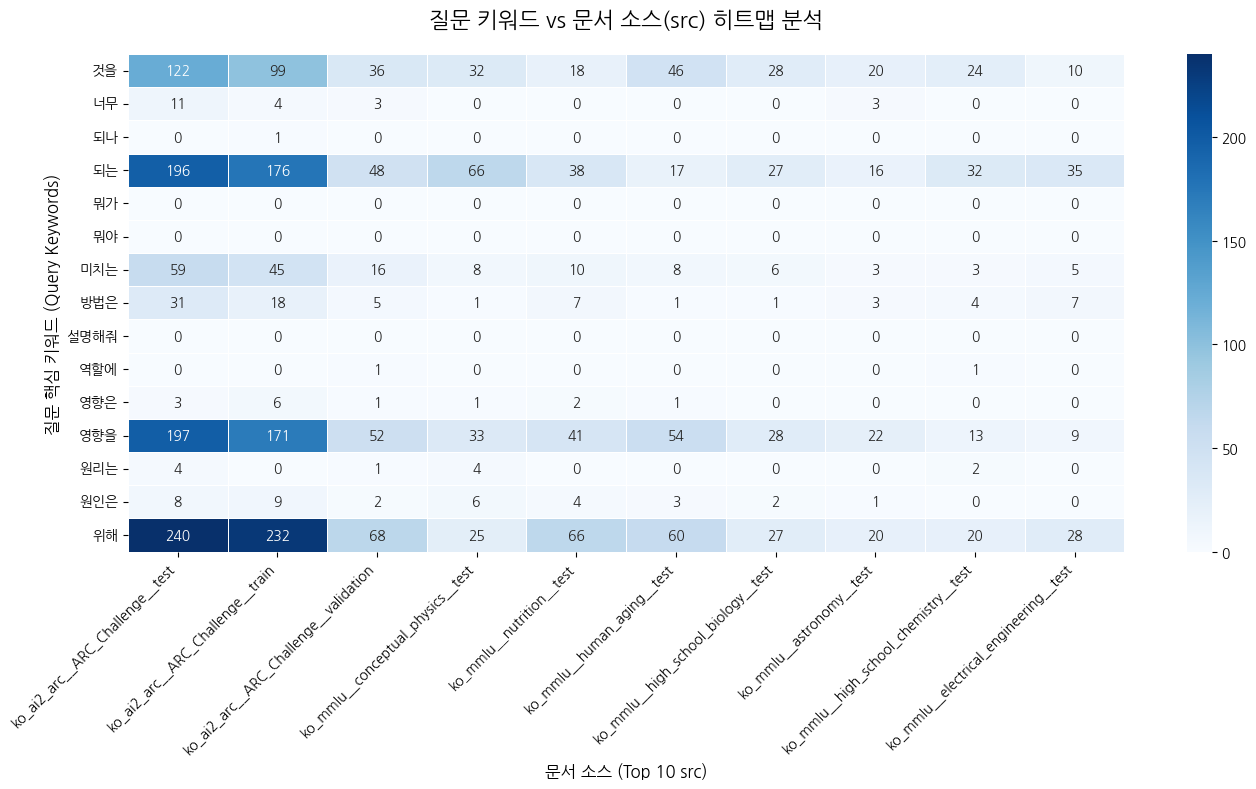

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.font_manager as fm
import os

# 1. 폰트 강제 등록 (가장 확실한 방법!)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    # Matplotlib 폰트 매니저에 직접 파일 경로를 밀어넣음
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
else:
    print("⚠️ 폰트 파일이 해당 경로에 없습니다. 처음 알려드린 !apt-get install -y fonts-nanum 을 실행했는지 확인해주세요.")
    
plt.rcParams['axes.unicode_minus'] = False

# 2. 질문(Query)에서 단어 추출
query_texts = eval_df['msg'].apply(lambda x: x[-1]['content'] if isinstance(x, list) else "").tolist()

# 2글자 이상 단어 추출, 상위 30개 뽑기
vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w{2,}\b', max_features=30)
vectorizer.fit(query_texts)
query_keywords_raw = vectorizer.get_feature_names_out()

# 불용어 수동 필터링
stopwords = ['대해', '알려줘', '어떤', '어떻게', '있는', '있을까', '가장', '위한', '관련', '무엇인가요', '무엇인지', '알려주세요']
query_keywords = [kw for kw in query_keywords_raw if kw not in stopwords][:15]

# 3. 상위 10개 소스(src) 선정
top_srcs = docs_df['src'].value_counts().head(10).index.tolist()

# 4. 교차 분석 매트릭스 (DataFrame) 생성 (0으로 초기화)
heatmap_data = pd.DataFrame(0, index=query_keywords, columns=top_srcs)

# 5. 매트릭스 값 채우기
filtered_docs = docs_df[docs_df['src'].isin(top_srcs)]

for _, row in filtered_docs.iterrows():
    src = row['src']
    content = row['content']
    for kw in query_keywords:
        if kw in content:
            heatmap_data.loc[kw, src] += 1

# 6. 히트맵 시각화
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', linewidths=.5)

plt.title('질문 키워드 vs 문서 소스(src) 히트맵 분석', fontsize=16, pad=20)
plt.xlabel('문서 소스 (Top 10 src)', fontsize=12)
plt.ylabel('질문 핵심 키워드 (Query Keywords)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()